# Fraud detection with XGBoost

Inspired by
- [XGBoost in Python from Start to Finish](https://www.youtube.com/watch?v=GrJP9FLV3FE) 


### For macOS users

You may get an error about **OpenMP** / **libomp.dylib** when importing XGBoost, it is recommended to install Apple’s OpenMP runtime 

`brew install libomp`


In [180]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
import random

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="notebook")
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_SEED = 42
IMAGE_DIR = "../../results/images/XGBoost"

random.seed(RANDOM_SEED)

### Load train / validation / test



In [181]:
DATA_ROOT = Path("../../data/processed/supervised")

train_df = pd.read_csv(DATA_ROOT / "train_data.csv")
val_df = pd.read_csv(DATA_ROOT / "val_data.csv")
test_df = pd.read_csv(DATA_ROOT / "test_data.csv")

feature_cols = [c for c in train_df.columns if c != "fraud"]

X_train = train_df[feature_cols]
y_train = train_df["fraud"]

X_val = val_df[feature_cols]
y_val = val_df["fraud"]

X_test = test_df[feature_cols]
y_test = test_df["fraud"]

print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)
print("Train fraud rate:", y_train.mean().round(6))
print("Val fraud rate:  ", y_val.mean().round(6))
print("Test fraud rate: ", y_test.mean().round(6))
print("Features:", len(feature_cols))

Train: (417847, 31) | Val: (87702, 31) | Test: (89093, 31)
Train fraud rate: 0.012636
Val fraud rate:   0.010946
Test fraud rate:  0.010775
Features: 30


### Train XGBoost for classification

### Hyperparameter Search

In [182]:
seen = set()
results = []

while len(results) < 10:
    params = {
        "learning_rate": random.choice([0.01, 0.05, 0.1]),
        "max_depth": random.choice([3, 4, 5, 6]),
        "subsample": random.choice([0.8, 0.9, 1.0])
    }

    key = tuple(params.items())
    if key in seen:
        continue
    seen.add(key)

    pos = int((y_train == 1).sum())
    neg = int((y_train == 0).sum())
    scale_pos_weight = neg / max(pos, 1)

    model = XGBClassifier(
        n_estimators=500,
        **params,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_SEED,
        tree_method="hist",
        early_stopping_rounds=50,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    
    y_pred = model.predict(X_val)
    probs_val = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    perc = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    roc_auc = roc_auc_score(y_val, probs_val)
    pr_auc = average_precision_score(y_val, probs_val)

    results.append({
        "params": params,
        "accuracy": acc,
        "precision": perc,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    })

In [183]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="pr_auc", ascending=False)

results_df

,params,accuracy,precision,recall,f1_score,roc_auc,pr_auc
8,"{'learning_rate': 0.05, 'max_depth': 5, 'subsa...",0.994470,0.674761,0.955208,0.790858,0.999246,0.953354
4,"{'learning_rate': 0.05, 'max_depth': 3, 'subsa...",0.991197,0.555886,0.973958,0.707797,0.999174,0.949733
6,"{'learning_rate': 0.1, 'max_depth': 3, 'subsam...",0.992532,0.598071,0.968750,0.739563,0.999131,0.948682
1,"{'learning_rate': 0.1, 'max_depth': 5, 'subsam...",0.993615,0.639470,0.955208,0.766082,0.999133,0.948101
0,"{'learning_rate': 0.1, 'max_depth': 3, 'subsam...",0.986967,0.455733,0.981250,0.622398,0.998973,0.940823
2,"{'learning_rate': 0.01, 'max_depth': 4, 'subsa...",0.983911,0.404246,0.991667,0.574359,0.998935,0.935291
5,"{'learning_rate': 0.01, 'max_depth': 4, 'subsa...",0.984196,0.408584,0.991667,0.578723,0.998923,0.934327
3,"{'learning_rate': 0.01, 'max_depth': 3, 'subsa...",0.983854,0.403308,0.990625,0.573237,0.998791,0.926829
7,"{'learning_rate': 0.01, 'max_depth': 6, 'subsa...",0.986591,0.448815,0.986458,0.616938,0.998879,0.921624
9,"{'learning_rate': 0.01, 'max_depth': 6, 'subsa...",0.986352,0.444288,0.984375,0.612245,0.998813,0.916242


In [184]:
best_results = results_df.iloc[0]
best_params = best_results['params']

print("Best hyperparameters:", best_params)
print("Validation Accuracy:", best_results['accuracy'])
print("Validation Precision:", best_results['precision'])
print("Validation Recall:", best_results['recall'])
print("Validation F1 Score:", best_results['f1_score'])
print("Validation ROC AUC:", best_results['roc_auc'])
print("Validation PR AUC:", best_results['pr_auc'])

Best hyperparameters: {'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8}
Validation Accuracy: 0.9944699094661468
Validation Precision: 0.6747608535688006
Validation Recall: 0.9552083333333333
Validation F1 Score: 0.7908581285036653
Validation ROC AUC: 0.9992456436904844
Validation PR AUC: 0.9533538427074928


In [185]:
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = neg / max(pos, 1)

model = XGBClassifier(
    n_estimators=2000,
    **best_params,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED,
    tree_method="hist",
    early_stopping_rounds=50,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=150,
)

print("Best iteration (0-based):", model.best_iteration)
print("Best validation score (aucpr):", model.best_score)

[0]	validation_0-aucpr:0.84563
[150]	validation_0-aucpr:0.94401
[300]	validation_0-aucpr:0.95146
[450]	validation_0-aucpr:0.95302
[516]	validation_0-aucpr:0.95310
Best iteration (0-based): 466
Best validation score (aucpr): 0.9533343492960319


In [186]:
probs_val = model.predict_proba(X_val)[:, 1]
precision, recall, threshold = precision_recall_curve(y_val, probs_val)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_index = np.argmax(f1_scores)
optimal_threshold = threshold[best_index]

probs_test = model.predict_proba(X_test)[:, 1]
y_pred = (probs_test >= optimal_threshold).astype(int)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:   ", recall_score(y_test, y_pred, zero_division=0))
print("F1:       ", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:  ", roc_auc_score(y_test, probs_test))
print("PR AUC:   ", average_precision_score(y_test, probs_test))

Accuracy:  0.9974408763875949
Precision: 0.9216589861751152
Recall:    0.8333333333333334
F1:        0.87527352297593
ROC AUC:   0.9991424773732125
PR AUC:    0.9469408898831677


In [187]:
probs_val = model.predict_proba(X_val)[:, 1]
precision, recall, threshold = precision_recall_curve(y_val, probs_val)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_index = np.argmax(f1_scores)
optimal_threshold = threshold[best_index]

probs_test = model.predict_proba(X_test)[:, 1]
y_pred = (probs_test >= optimal_threshold).astype(int)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:   ", recall_score(y_test, y_pred, zero_division=0))
print("F1:       ", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:  ", roc_auc_score(y_test, probs_test))
print("PR AUC:   ", average_precision_score(y_test, probs_test))

# Save the model and threshold
Path("../../results/models").mkdir(parents=True, exist_ok=True)
joblib.dump({"model": model, "threshold": optimal_threshold}, '../../results/models/xgboost.pkl')

Accuracy:  0.9974408763875949
Precision: 0.9216589861751152
Recall:    0.8333333333333334
F1:        0.87527352297593
ROC AUC:   0.9991424773732125
PR AUC:    0.9469408898831677


['../../results/models/xgboost.pkl']

### XGBoost Tree Visualisation



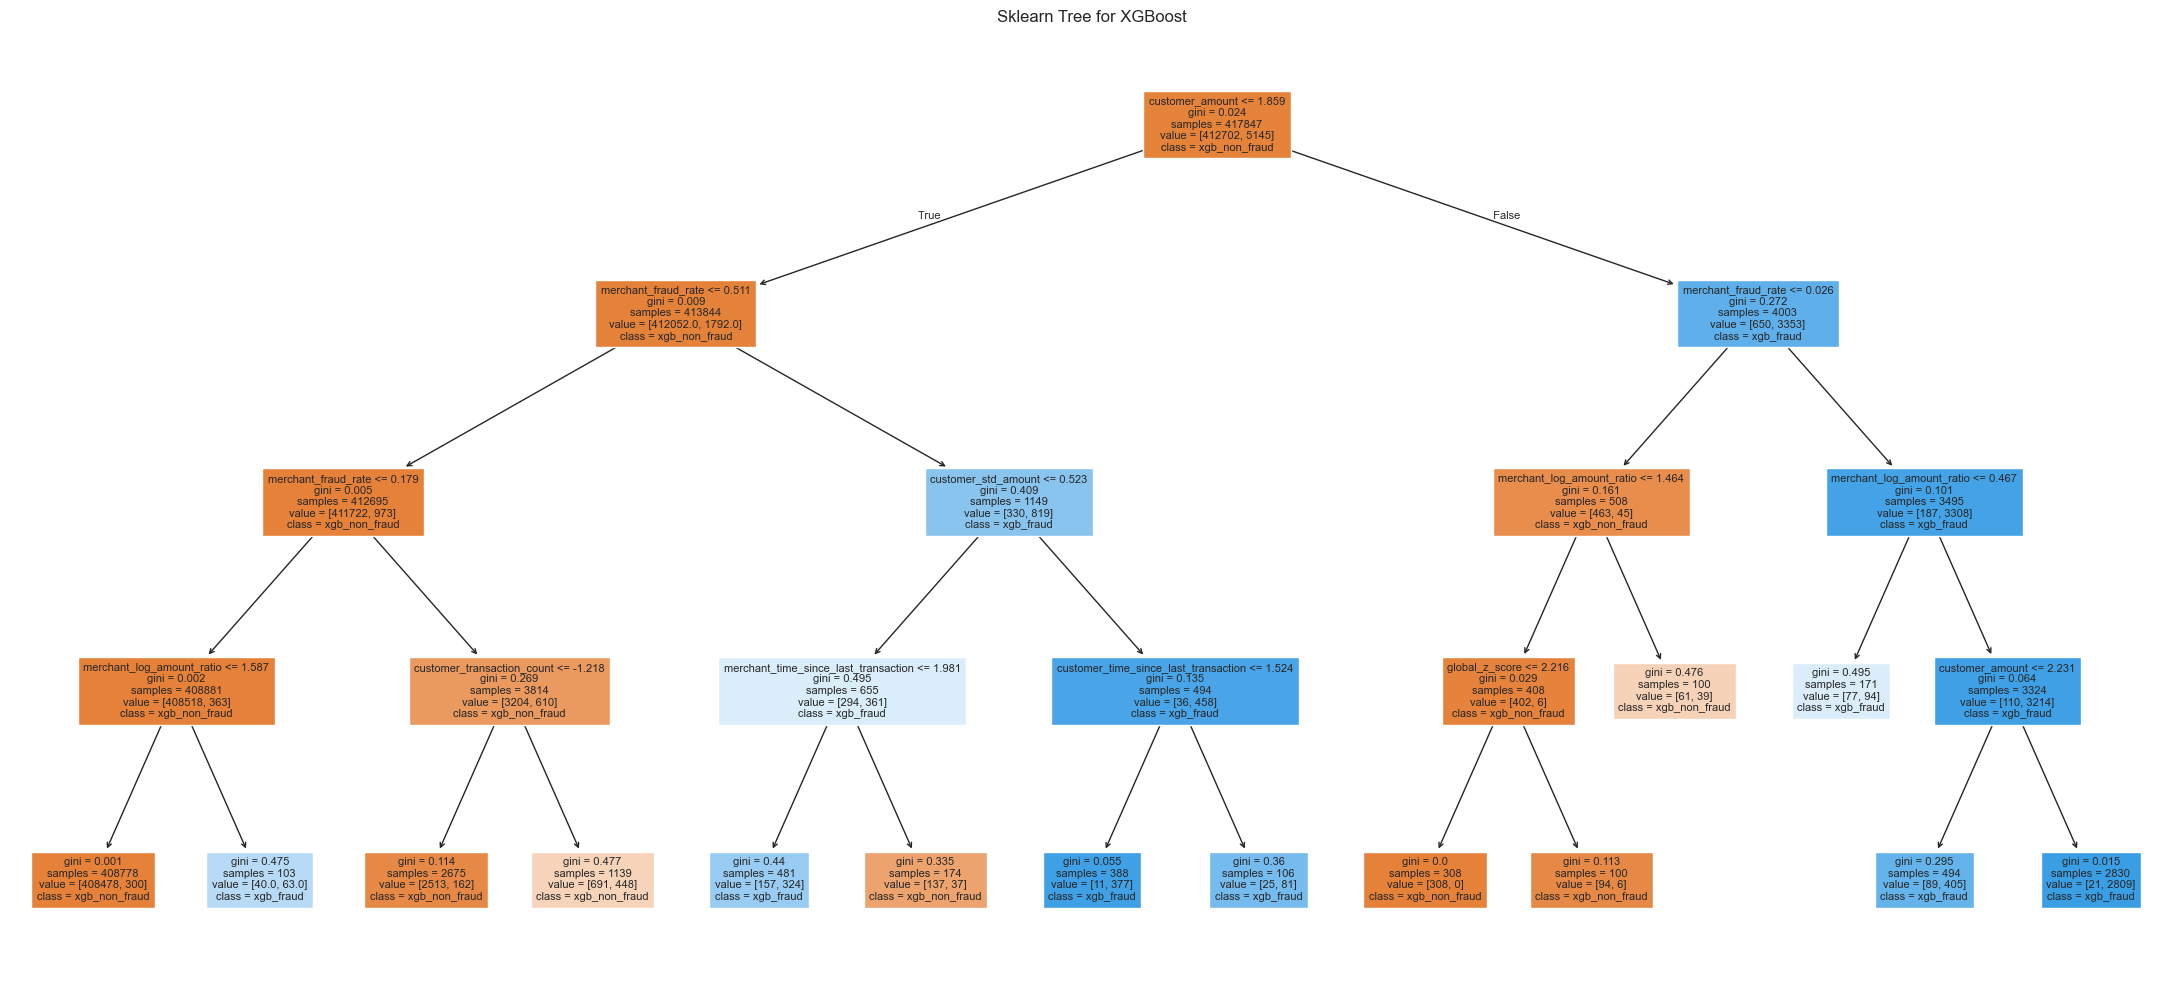

In [188]:
xgb_prob_train = model.predict_proba(X_train)[:, 1]
xgb_label_train = (xgb_prob_train >= optimal_threshold).astype(int)

decision_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=100, random_state=RANDOM_SEED)
decision_tree.fit(X_train, xgb_label_train)

plt.figure(figsize=(22, 10))
plot_tree(
    decision_tree,
    feature_names=feature_cols,
    class_names=["xgb_non_fraud", "xgb_fraud"],
    filled=True,
    max_depth=10,
    fontsize=8,
)
plt.title("Sklearn Tree for XGBoost")
plt.tight_layout()
plt.show()


### PR AUC curve


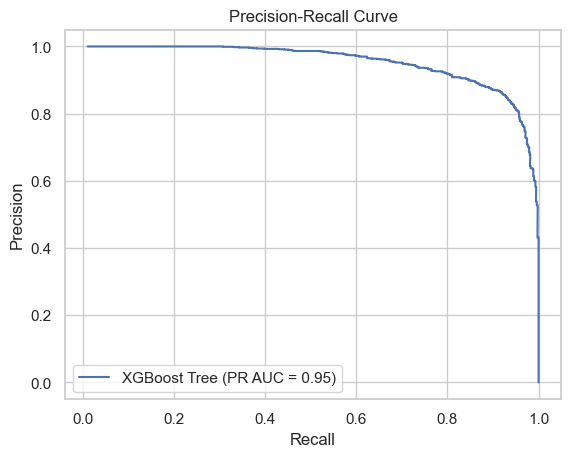

In [189]:
from pathlib import Path

plt.plot(precision, recall, label=f'XGBoost Tree (PR AUC = {(average_precision_score(y_test, probs_test)):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
Path(IMAGE_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f'{IMAGE_DIR}/xgboost_pr_curve_validation.svg')
plt.show()

### Confusion matrix based on threshold

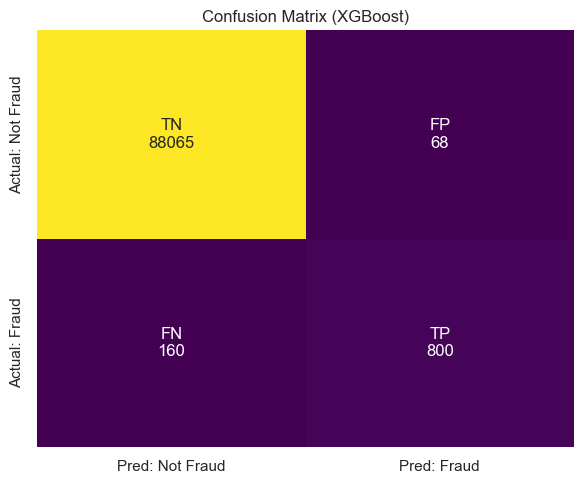

In [190]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

labels = [[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="viridis",
    xticklabels=["Pred: Not Fraud", "Pred: Fraud"],
    yticklabels=["Actual: Not Fraud", "Actual: Fraud"],
    ax=ax,
    cbar=False
)
ax.set_title("Confusion Matrix (XGBoost)")
plt.tight_layout()
plt.show()

### Feature importance

,feature,importance
0,merchant_fraud_rate,0.681512
1,global_log_median_amount_ratio,0.038233
2,global_z_score,0.030580
3,customer_amount,0.027254
4,merchant_transaction_count,0.027132
5,merchant_std_amount,0.019530
6,customer_std_amount,0.018470
7,merchant_log_amount_ratio,0.016364
8,customer_transaction_count,0.011731
9,customer_time_since_last_transaction,0.011029


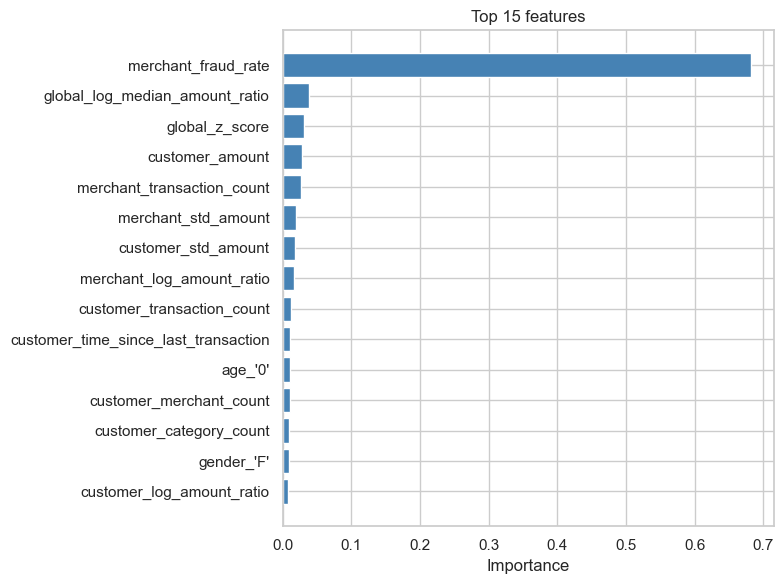

In [191]:
fi = (
    pd.DataFrame({"feature": feature_cols, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(fi.head(20))

top_k = 15
sub = fi.head(top_k).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(sub["feature"], sub["importance"], color="steelblue")
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_k} features")
plt.tight_layout()
plt.show()

Python(7935) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7936) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7937) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7938) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7939) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7940) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7941) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7942) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7943) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(7944) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


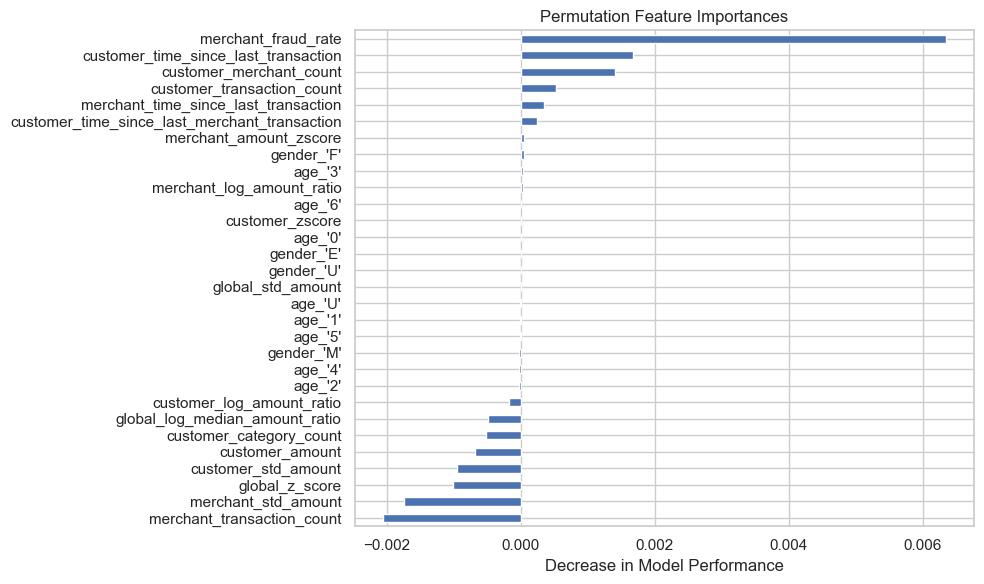

In [192]:
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

perm_imp = pd.Series(result.importances_mean, index=X_train.columns)
perm_imp = perm_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
perm_imp.sort_values().plot(kind='barh')
plt.title("Permutation Feature Importances")
plt.xlabel("Decrease in Model Performance")
plt.tight_layout()
plt.show()